In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import sys
print(sys.executable)

c:\Users\gupta\OneDrive\New folder\customer_churn\venv\Scripts\python.exe


In [6]:
%pip install pandas numpy matplotlib seaborn scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: c:\Users\gupta\OneDrive\New folder\customer_churn\venv\Scripts\python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
import urllib.request

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

urllib.request.urlretrieve(
    url,
    "../data/Telco-Customer-Churn.csv"
)

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [9]:
import urllib.request

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

urllib.request.urlretrieve(
    url,
    "../data/Telco-Customer-Churn.csv"
)

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [10]:
import os

print(os.path.exists("../data/Telco-Customer-Churn.csv"))

True


In [11]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
import sys
print(sys.executable)

c:\Users\gupta\OneDrive\New folder\customer_churn\venv\Scripts\python.exe


In [13]:
df.shape
df.info()
df["Churn"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [14]:
df["TotalCharges"].str.strip().eq("").sum()

np.int64(11)

In [15]:
df["TotalCharges"].str.strip().eq("").sum()

np.int64(11)

In [16]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [17]:
df["TotalCharges"].tail(20)
df["TotalCharges"].dtype

dtype('O')

In [18]:
df = df.dropna(subset=["TotalCharges"])
df.shape

(7043, 21)

In [19]:
df["TotalCharges"].str.strip().eq("").sum()

np.int64(11)

In [20]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [21]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [22]:
df = df.dropna(subset=["TotalCharges"])
df.shape

(7032, 21)

In [23]:
df["TotalCharges"].dtype

dtype('float64')

In [24]:
df["Churn"].value_counts()
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

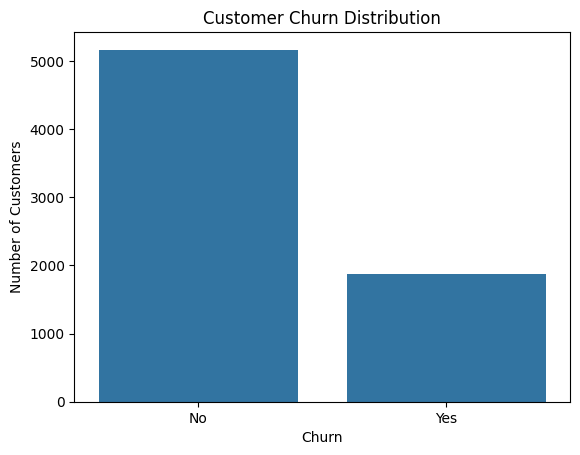

In [25]:
sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [26]:
df.groupby("Churn")["tenure"].mean()

Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64

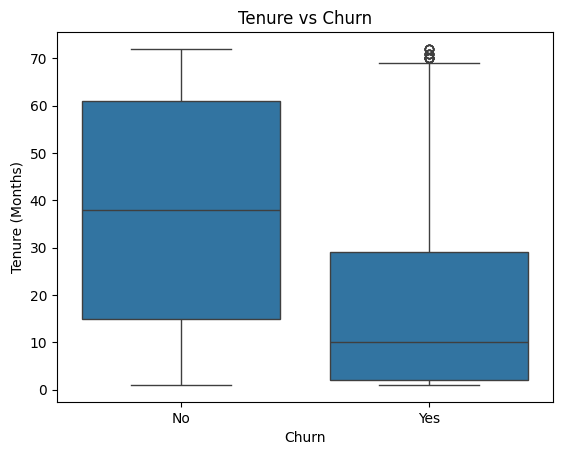

In [27]:
sns.boxplot(data=df, x="Churn", y="tenure")

plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

In [28]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


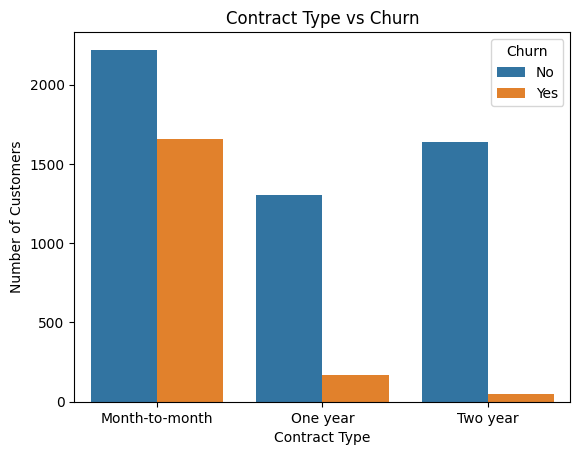

In [29]:
sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

In [30]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

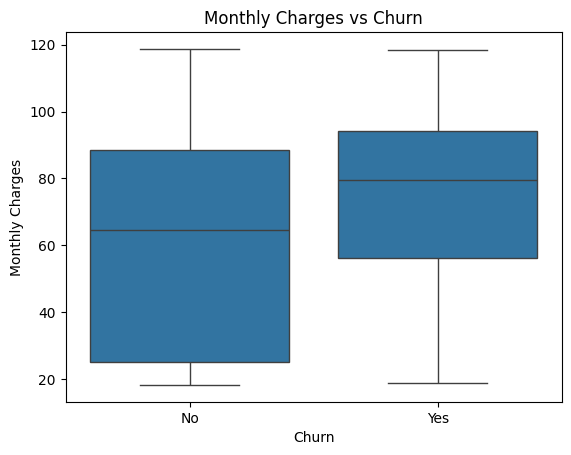

In [31]:

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [32]:
pd.crosstab(df["InternetService"], df["Churn"])

Churn,No,Yes
InternetService,,
DSL,1957,459
Fiber optic,1799,1297
No,1407,113


In [33]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


In [34]:
df[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]].corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.015683,0.219874,0.102411
tenure,0.015683,1.000000,0.246862,0.825880
MonthlyCharges,0.219874,0.246862,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


In [35]:
df = df.drop("customerID", axis=1)

In [36]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [37]:
y = y.map({"No": 0, "Yes": 1})

In [38]:
y.value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [39]:
categorical_cols = X.select_dtypes(include="object").columns

categorical_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [40]:
numerical_cols = X.select_dtypes(exclude="object").columns

numerical_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [43]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5625, 19)
X_test: (1407, 19)
y_train: (5625,)
y_test: (1407,)


In [44]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [45]:
print("Before encoding:", X_train.shape)
print("After encoding:", X_train_processed.shape)

Before encoding: (5625, 19)
After encoding: (5625, 45)


In [46]:
from sklearn.linear_model import LogisticRegression

In [47]:
model_lr = LogisticRegression(max_iter=1000)

In [48]:
model_lr.fit(X_train_processed, y_train)

c:\Users\gupta\OneDrive\New folder\customer_churn\venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [49]:
y_pred_lr = model_lr.predict(X_test_processed)

In [50]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [51]:
accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8024164889836531
Precision: 0.6445783132530121
Recall   : 0.5721925133689839
F1 Score : 0.6062322946175638


In [52]:
cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[915 118]
 [160 214]]


In [53]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.64      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



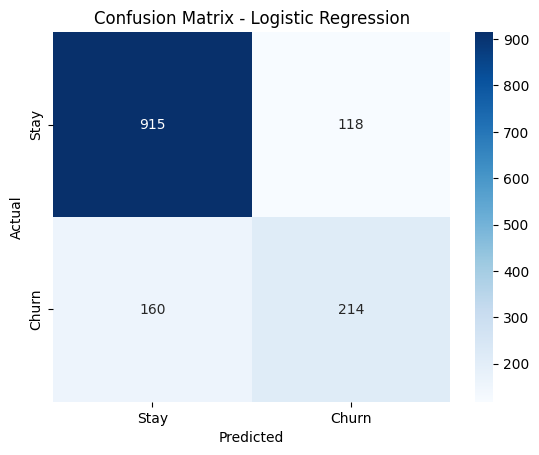

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stay", "Churn"],
    yticklabels=["Stay", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [55]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_lr
})

print(results.head(10))

   Actual  Predicted
0       0          0
1       0          1
2       0          0
3       1          0
4       0          0
5       1          0
6       0          0
7       0          0
8       1          1
9       0          0


In [56]:
print("Total test samples:", len(y_test))
print("Correct predictions:", (y_test == y_pred_lr).sum())
print("Wrong predictions:", (y_test != y_pred_lr).sum())

Total test samples: 1407
Correct predictions: 1129
Wrong predictions: 278


In [57]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(random_state=42)

model_dt.fit(X_train_processed, y_train)

y_pred_dt = model_dt.predict(X_test_processed)

In [58]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("Accuracy :", accuracy_dt)
print("Precision:", precision_dt)
print("Recall   :", recall_dt)
print("F1 Score :", f1_dt)

Decision Tree Results
Accuracy : 0.7221037668798863
Precision: 0.4780361757105943
Recall   : 0.4946524064171123
F1 Score : 0.48620236530880423


In [59]:
y_train_pred_dt = model_dt.predict(X_train_processed)

train_accuracy_dt = accuracy_score(y_train, y_train_pred_dt)
test_accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Training Accuracy:", train_accuracy_dt)
print("Test Accuracy:", test_accuracy_dt)

Training Accuracy: 0.9987555555555555
Test Accuracy: 0.7221037668798863


In [60]:
for depth in [3, 5, 7, 10, 15]:

    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    tree.fit(X_train_processed, y_train)

    train_pred = tree.predict(X_train_processed)
    test_pred = tree.predict(X_test_processed)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    print(
        "Depth:", depth,
        "| Train:", round(train_acc, 3),
        "| Test:", round(test_acc, 3)
    )

Depth: 3 | Train: 0.791 | Test: 0.778
Depth: 5 | Train: 0.799 | Test: 0.79
Depth: 7 | Train: 0.823 | Test: 0.778
Depth: 10 | Train: 0.875 | Test: 0.756
Depth: 15 | Train: 0.966 | Test: 0.729


In [61]:
model_dt_tuned = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

model_dt_tuned.fit(X_train_processed, y_train)

y_pred_dt_tuned = model_dt_tuned.predict(X_test_processed)

In [62]:
print("Tuned Decision Tree Results")

print("Accuracy :", accuracy_score(y_test, y_pred_dt_tuned))
print("Precision:", precision_score(y_test, y_pred_dt_tuned))
print("Recall   :", recall_score(y_test, y_pred_dt_tuned))
print("F1 Score :", f1_score(y_test, y_pred_dt_tuned))

Tuned Decision Tree Results
Accuracy : 0.7896233120113717
Precision: 0.6020942408376964
Recall   : 0.6149732620320856
F1 Score : 0.6084656084656085


In [63]:
from sklearn.model_selection import GridSearchCV

In [64]:
param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [65]:
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [66]:
grid_search.fit(X_train_processed, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [67]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV F1 Score: 0.5742944228427016


In [68]:
best_tree = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV F1 Score: 0.5742944228427016


In [69]:
y_pred_best = best_tree.predict(X_test_processed)

In [70]:
print("Final Tuned Decision Tree Results")

print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))

Final Tuned Decision Tree Results
Accuracy : 0.7896233120113717
Precision: 0.6020942408376964
Recall   : 0.6149732620320856
F1 Score : 0.6084656084656085


In [71]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model_rf.fit(X_train_processed, y_train)

y_pred_rf = model_rf.predict(X_test_processed)

In [72]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)

Random Forest Results
Accuracy : 0.7924662402274343
Precision: 0.6375838926174496
Recall   : 0.5080213903743316
F1 Score : 0.5654761904761905


In [73]:
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [74]:
grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [75]:
grid_search_rf.fit(X_train_processed, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [76]:
print("Best Parameters:", grid_search_rf.best_params_)
print("Best CV F1 Score:", grid_search_rf.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1 Score: 0.5836815722947003


In [77]:
best_rf = grid_search_rf.best_estimator_

In [79]:
y_pred_best_rf = best_rf.predict(X_test_processed)

In [80]:
print("Final Tuned Random Forest Results")

print("Accuracy :", accuracy_score(y_test, y_pred_best_rf))
print("Precision:", precision_score(y_test, y_pred_best_rf))
print("Recall   :", recall_score(y_test, y_pred_best_rf))
print("F1 Score :", f1_score(y_test, y_pred_best_rf))

Final Tuned Random Forest Results
Accuracy : 0.7953091684434968
Precision: 0.6414473684210527
Recall   : 0.5213903743315508
F1 Score : 0.5752212389380531


In [81]:
from sklearn.metrics import roc_auc_score

y_prob_lr = model_lr.predict_proba(X_test_processed)[:, 1]

roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression ROC-AUC:", roc_auc_lr)

Logistic Regression ROC-AUC: 0.8364260163275026


In [82]:
y_prob_dt = model_dt_tuned.predict_proba(X_test_processed)[:, 1]

roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Tuned Decision Tree ROC-AUC:", roc_auc_dt)

Tuned Decision Tree ROC-AUC: 0.8296250472379394


In [83]:
y_prob_rf = best_rf.predict_proba(X_test_processed)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Tuned Random Forest ROC-AUC:", roc_auc_rf)

Tuned Random Forest ROC-AUC: 0.8311224252087529


In [84]:
import joblib

joblib.dump(preprocessor, "../model/preprocessor.pkl")

['../model/preprocessor.pkl']

In [85]:
joblib.dump(model_lr, "../model/logistic_regression.pkl")

['../model/logistic_regression.pkl']